![manufacturing gears](manufacturing.jpg)

Manufacturing processes for any product is like putting together a puzzle. Products are pieced together step by step, and keeping a close eye on the process is important.

For this project, you're supporting a team that wants to improve how they monitor and control a manufacturing process. The goal is to implement a more methodical approach known as statistical process control (SPC). SPC is an established strategy that uses data to determine whether the process works well. Processes are only adjusted if measurements fall outside of an acceptable range. 

This acceptable range is defined by an upper control limit (UCL) and a lower control limit (LCL), the formulas for which are:

$ucl = avg\_height + 3 * \frac{stddev\_height}{\sqrt{5}}$

$lcl = avg\_height - 3 * \frac{stddev\_height}{\sqrt{5}}$

The UCL defines the highest acceptable height for the parts, while the LCL defines the lowest acceptable height for the parts. Ideally, parts should fall between the two limits.

Using SQL window functions and nested queries, you'll analyze historical manufacturing data to define this acceptable range and identify any points in the process that fall outside of the range and therefore require adjustments. This will ensure a smooth running manufacturing process consistently making high-quality products.

## The data
The data is available in the `manufacturing_parts` table which has the following fields:
- `item_no`: the item number
- `length`: the length of the item made
- `width`: the width of the item made
- `height`: the height of the item made
- `operator`: the operating machine

# **SQL(Control Limits + Alert Flag)**

In [37]:
-- Flag whether the height of a product is within the control limits
SELECT
    b.*,
    CASE
        WHEN b.height NOT BETWEEN b.lcl AND b.ucl THEN TRUE
        ELSE FALSE
    END AS alert
FROM (
    SELECT
        a.*, 
        a.avg_height + 3 * a.stddev_height / SQRT(5) AS ucl, 
        a.avg_height - 3 * a.stddev_height / SQRT(5) AS lcl  
    FROM (
        SELECT 
            operator,
            ROW_NUMBER() OVER w AS row_number, 
            height, 
            AVG(height) OVER w AS avg_height, 
            STDDEV(height) OVER w AS stddev_height
        FROM manufacturing_parts 
        WINDOW w AS (
            PARTITION BY operator 
            ORDER BY item_no 
            ROWS BETWEEN 4 PRECEDING AND CURRENT ROW
        )
    ) AS a
    WHERE a.row_number >= 5
) AS b;


,operator,row_number,height,avg_height,stddev_height,ucl,lcl,alert
0,Op-1,5,19.46,19.778,1.062812,21.203912,18.352088,False
1,Op-1,6,20.36,19.912,1.090812,21.375477,18.448523,False
2,Op-1,7,20.22,20.030,1.084574,21.485108,18.574892,False
3,Op-1,8,21.03,19.934,0.931225,21.183369,18.684631,False
4,Op-1,9,19.78,20.170,0.598832,20.973418,19.366582,False
...,...,...,...,...,...,...,...,...
415,Op-9,31,19.01,18.904,0.203052,19.176422,18.631578,False
416,Op-9,32,18.57,18.864,0.250260,19.199759,18.528241,False
417,Op-9,33,20.91,19.266,0.952276,20.543613,17.988387,True
418,Op-9,34,21.24,19.678,1.291112,21.410208,17.945792,False


# Python Analysis (Data Preparation)

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("parts.csv")

# Sort data
df = df.sort_values(["operator", "item_no"])

# Rolling averages
df["avg_height"] = df.groupby("operator")["height"].transform(
    lambda x: x.rolling(window=5).mean()
)

df["stddev_height"] = df.groupby("operator")["height"].transform(
    lambda x: x.rolling(window=5).std()
)

# Control limits
df["ucl"] = df["avg_height"] + 3 * df["stddev_height"] / np.sqrt(5)
df["lcl"] = df["avg_height"] - 3 * df["stddev_height"] / np.sqrt(5)

# Alerts
df["alert"] = ~df["height"].between(df["lcl"], df["ucl"])

# Remove NaN rows (first 4 per operator)
df = df.dropna().reset_index(drop=True)

print(f"Total units analyzed: {len(df)}")
print(f"Alerts detected: {df['alert'].sum()}")
print(f"Alert rate: {(df['alert'].mean() * 100):.2f}%")

Total units analyzed: 420
Alerts detected: 57
Alert rate: 13.57%


# Operator Summary

In [39]:
summary = df.groupby("operator").agg(
    total_units=("height", "count"),
    alerts=("alert", "sum"),
    alert_rate=("alert", "mean")
).round(3)

summary["alert_rate"] = summary["alert_rate"] * 100
summary = summary.sort_values("alert_rate", ascending=False)

print("\nOperator Summary:")
print(summary)


Operator Summary:
          total_units  alerts  alert_rate
operator                                 
Op-4               17       4        23.5
Op-5               29       6        20.7
Op-16              21       4        19.0
Op-2               21       4        19.0
Op-20              17       3        17.6
Op-13              17       3        17.6
Op-14              31       5        16.1
Op-7               29       4        13.8
Op-1               22       3        13.6
Op-15              15       2        13.3
Op-8               16       2        12.5
Op-3               25       3        12.0
Op-19              17       2        11.8
Op-10              26       3        11.5
Op-17              19       2        10.5
Op-9               31       3         9.7
Op-11              12       1         8.3
Op-6               14       1         7.1
Op-12              16       1         6.2
Op-18              25       1         4.0


# Control Chart

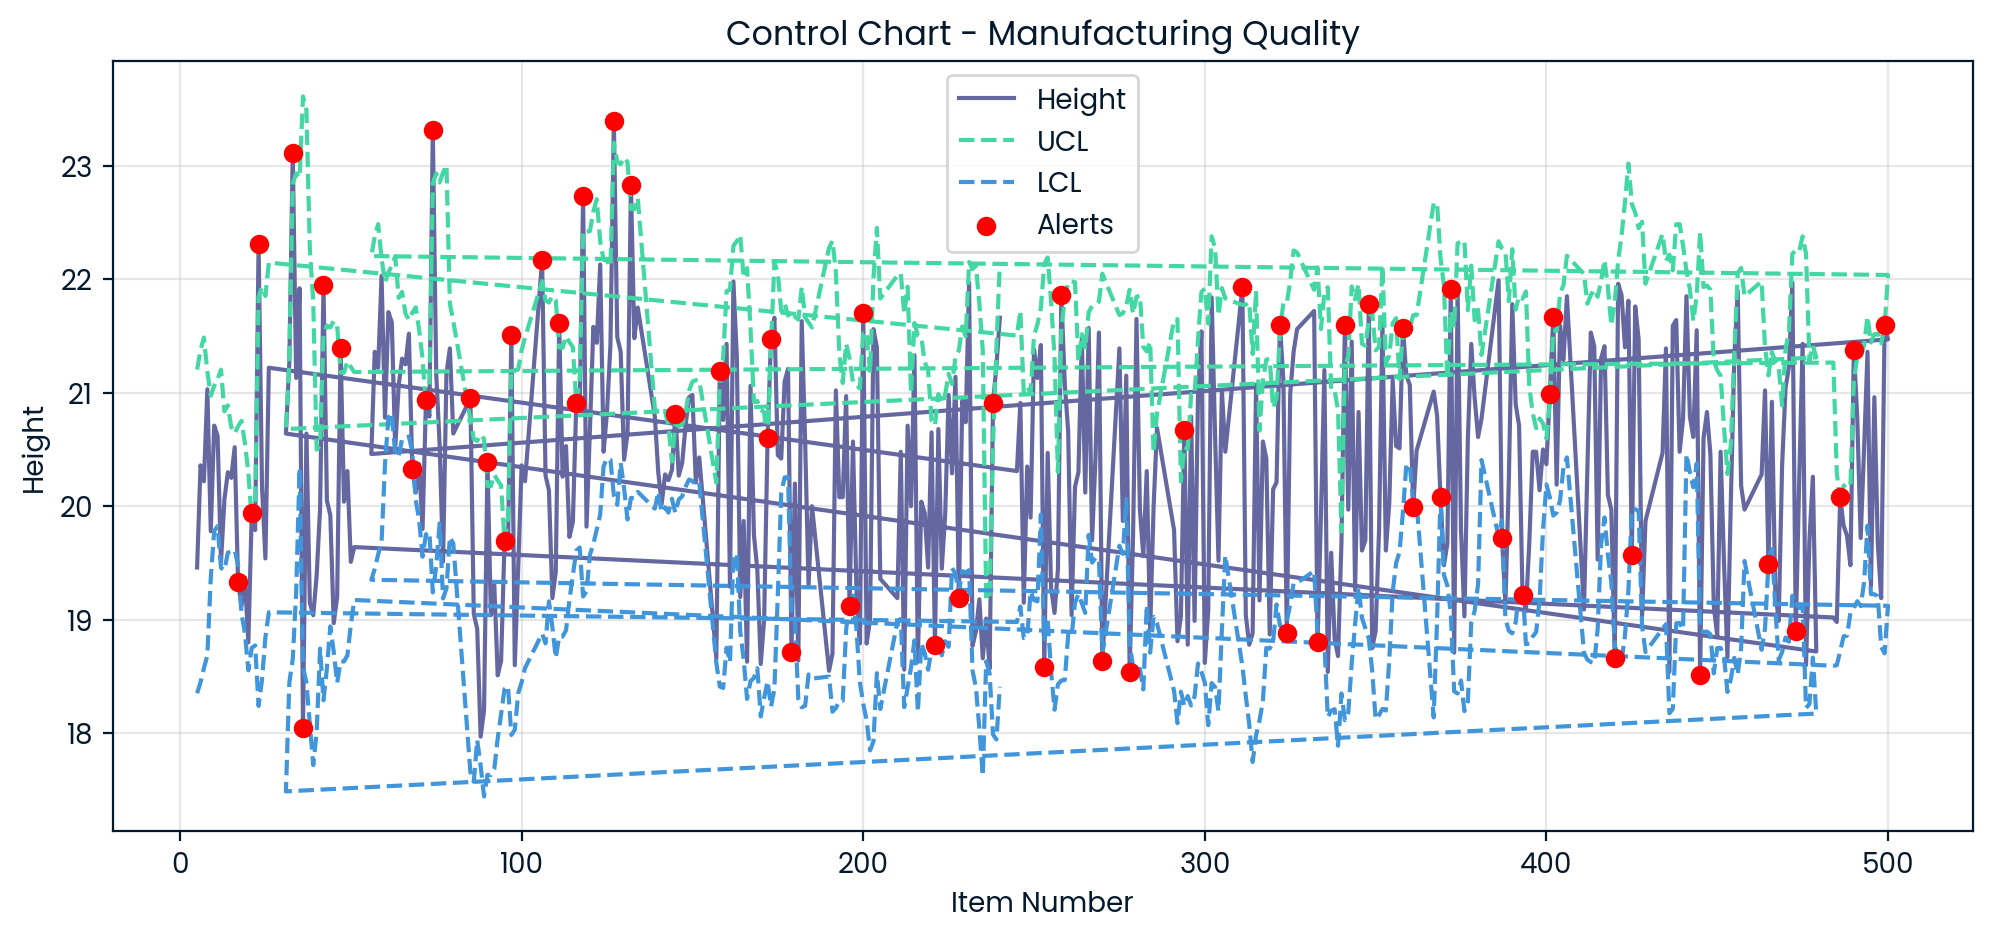

In [40]:
plt.figure(figsize=(12, 5))

# Line plot
plt.plot(df["item_no"], df["height"], label="Height")
plt.plot(df["item_no"], df["ucl"], linestyle="--", label="UCL")
plt.plot(df["item_no"], df["lcl"], linestyle="--", label="LCL")

# Alerts
alerts = df[df["alert"]]
plt.scatter(alerts["item_no"], alerts["height"], color="red", label="Alerts", zorder=5)

# Labels
plt.xlabel("Item Number")
plt.ylabel("Height")
plt.title("Control Chart - Manufacturing Quality")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

# Simple Insights

In [41]:
print("\nSummary:")
print(f"- Total Units: {len(df)}")
print(f"- Alerts: {df['alert'].sum()}")
print(f"- Alert Rate: {(df['alert'].mean() * 100):.2f}%")
print(f"- Operators with alerts: {df[df['alert']]['operator'].nunique()}")

# Operators with highest issues
print("\nOperators with highest alert rates:")
print(summary.head(3))


Summary:
- Total Units: 420
- Alerts: 57
- Alert Rate: 13.57%
- Operators with alerts: 20

Operators with highest alert rates:
          total_units  alerts  alert_rate
operator                                 
Op-4               17       4        23.5
Op-5               29       6        20.7
Op-16              21       4        19.0


# Conclusion

This analysis used Statistical Process Control (SPC) to monitor manufacturing quality and identify measurements outside control limits.

### Key Observations
- **57 alerts (13.57% of production)** fell outside control limits, indicating notable process variation
- Alert rates varied significantly across operators: Op-4, Op-5, and Op-16 showed the highest rates (19-23.5%)
- The process could benefit from targeted investigation of these operators to reduce variability

### Next Steps
- Explore additional features such as length and width for root cause analysis
- Analyze trends over time to detect patterns or shifts
- Build a real-time monitoring dashboard for early alert detection